
It contains 3 samples single-cell data. One normal B1, two tumor samples T1 and T2



In [1]:
import scanpy as sc
import anndata
import os



dir0 = "/stomics_data/liminData/spatial_related_codes/spatial_biology/Visium/P19"
outdir = f"{dir0}/analysis/single_cell"
os.makedirs(outdir, exist_ok=True)
sc.settings.figdir = outdir


In [2]:
adata = sc.read_h5ad(f"{dir0}/data/10X_Lung_Healthy_Background_Annotated_v2.h5ad")
adata

AnnData object with n_obs × n_vars = 392604 × 25718
    obs: 'n_genes', 'patient', 'sample', 'environment', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'sex', 'age', 'sorting', 'smoking history', 'cancer stage', 'tumour type', '# isolated cells', '# estimated cells', 'sangerID', 'cellranger', 'genome', 'batch', 'patient_sample', 'exp', 'n_counts', 'doublet_scores', 'S_score', 'G2M_score', 'phase', 'PHASE', 'leiden', 'leiden_new_cmcells_v2', 'leiden_new_bcells_v5', 'leiden_new_mastcells_v3', 'leiden_new_myeloid_v6', 'leiden_new_nkcells_v4', 'leiden_new_stroma_v11', 'leiden_new_tcells_v6', 'leiden_new_broad_v3', 'Cell types', 'Cell types v2', 'Cell types v3', 'Cell types v4', 'Cell types v5', 'Cell types v6', 'Cell types v7', 'Cell types v8', 'Cell types v9', 'Cell types v10', 'Cell types v11', 'Cell types v12'
    var: 'feature_types', 'n_cells', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm',

In [13]:
# sub = adata[adata.obs['patient_sample'] == "Patient 19 Background 1"].copy()
# sub.write_h5ad(f"{outdir}/patient19_background1_sc_annotated.h5ad")

# p15 = ["Patient 15 Background 1", "Patient 15 Background 2"]
# sub = adata[adata.obs['patient_sample'].isin(p15)].copy()
# sub.write_h5ad(f"{outdir}/patient15_background1n2_sc_annotated.h5ad")


adata15 = sc.read_h5ad(f"{outdir}/patient15_background1n2_sc_annotated.h5ad")
print(adata15)
adata19 = sc.read_h5ad(f"{outdir}/patient19_background1_sc_annotated.h5ad")
print(adata19)

AnnData object with n_obs × n_vars = 14295 × 25718
    obs: 'n_genes', 'patient', 'sample', 'environment', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'sex', 'age', 'sorting', 'smoking history', 'cancer stage', 'tumour type', '# isolated cells', '# estimated cells', 'sangerID', 'cellranger', 'genome', 'batch', 'patient_sample', 'exp', 'n_counts', 'doublet_scores', 'S_score', 'G2M_score', 'phase', 'PHASE', 'leiden', 'leiden_new_cmcells_v2', 'leiden_new_bcells_v5', 'leiden_new_mastcells_v3', 'leiden_new_myeloid_v6', 'leiden_new_nkcells_v4', 'leiden_new_stroma_v11', 'leiden_new_tcells_v6', 'leiden_new_broad_v3', 'Cell types', 'Cell types v2', 'Cell types v3', 'Cell types v4', 'Cell types v5', 'Cell types v6', 'Cell types v7', 'Cell types v8', 'Cell types v9', 'Cell types v10', 'Cell types v11', 'Cell types v12'
    var: 'feature_types', 'n_cells', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 

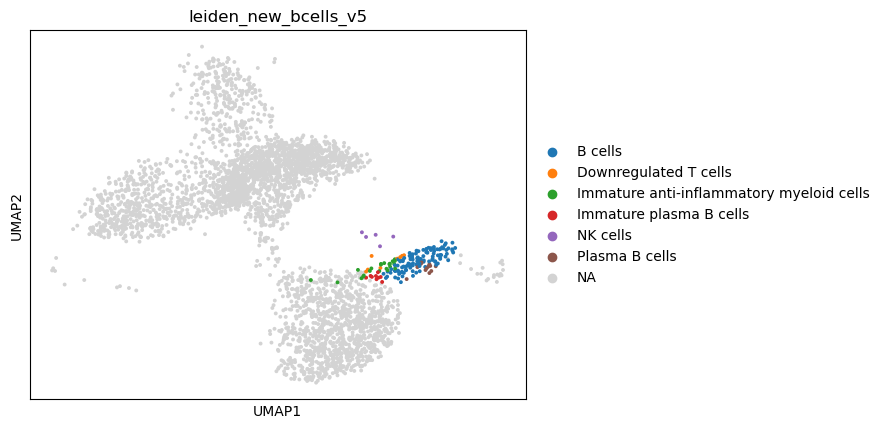

In [18]:
sc.pl.umap(adata19, color="leiden_new_bcells_v5", wspace=0.4)

In [19]:
file_dir = f"{dir0}/analysis/h5ad/"
samples = ["B1", "T1", "T2"]

# Normal sample:
filep = f"{file_dir}/B1_singlecell.h5ad"
adata = sc.read_h5ad(filep)

adata.var_names_make_unique()
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# filtering
adata = adata[adata.obs.n_genes_by_counts >= 180, :]
adata = adata[adata.obs.n_genes_by_counts <= 6000, :]
adata = adata[adata.obs.total_counts >= 400, :]
adata = adata[adata.obs.total_counts <= 100000, :]
adata = adata[adata.obs.pct_counts_mt <= 20, :]

# normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata



/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [20]:
# Select highly variable genes across the combined datasets
sc.pp.highly_variable_genes(adata, min_mean=0.0125)
adata = adata[:, adata.var.highly_variable].copy()

# scale data and run PCA (required before Harmony)
sc.pp.scale(adata, max_value=10, zero_center=False)
sc.tl.pca(adata, svd_solver="arpack")

sc.pp.neighbors(adata, use_rep="X_pca")
# Generate UMAP embeddings and clusters
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1)

# Plot to verify integration success
sc.pl.umap(adata, color="leiden", wspace=0.4)

/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_137814/1135745978.py:12: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1)


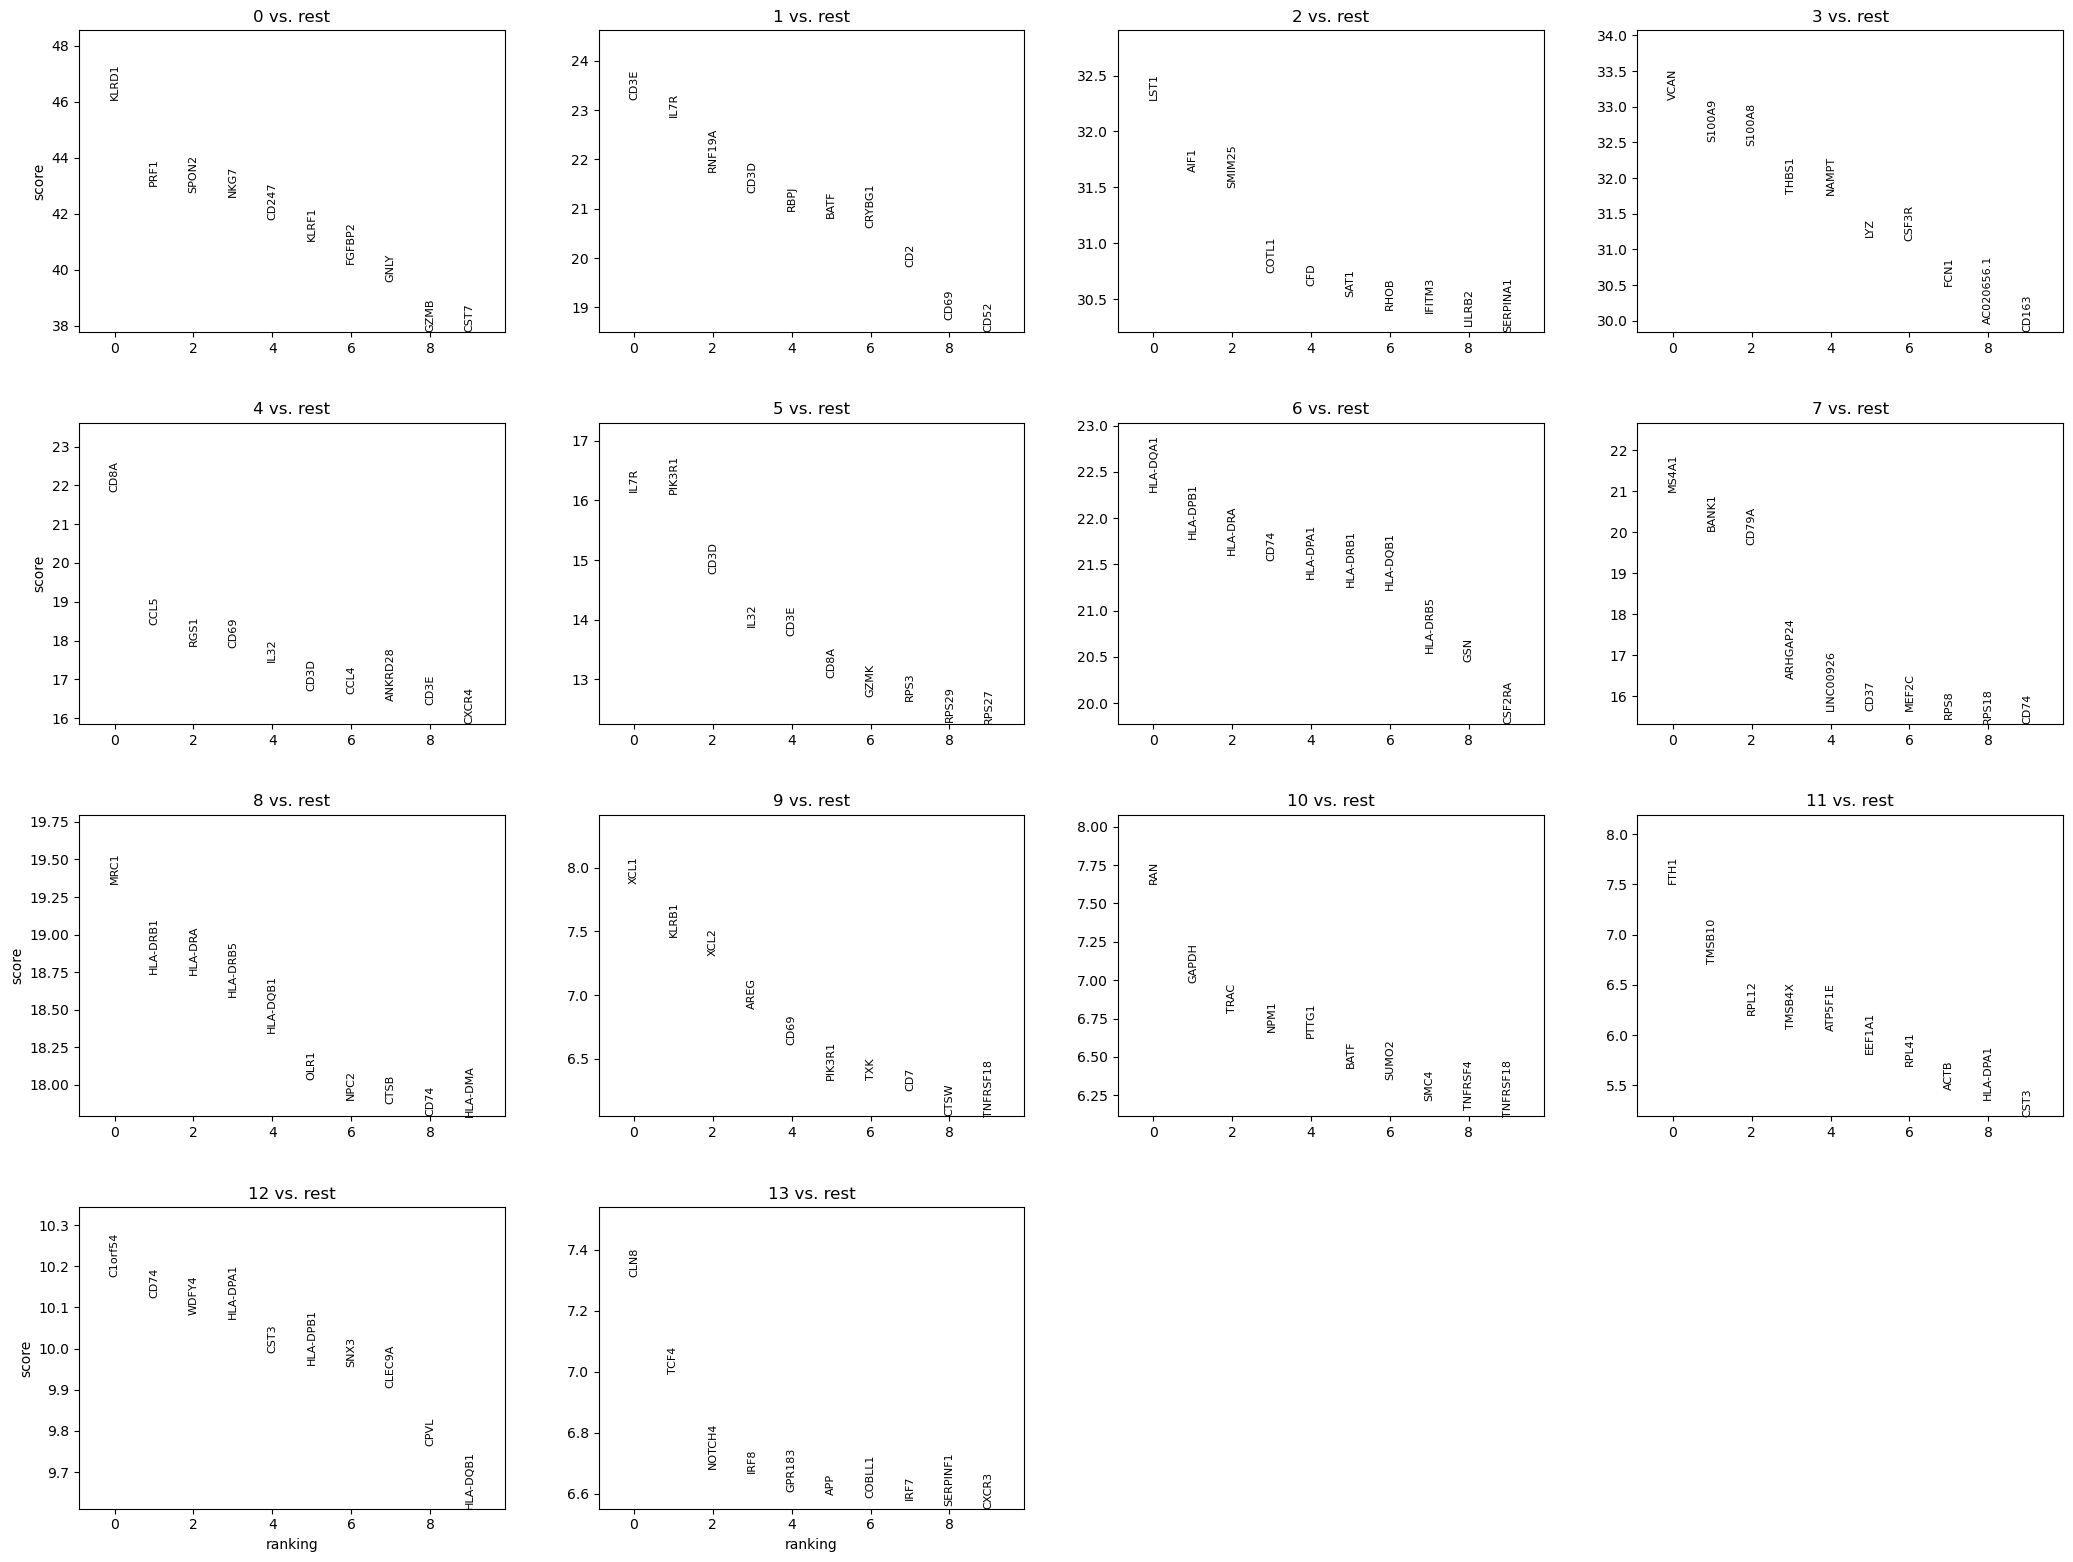

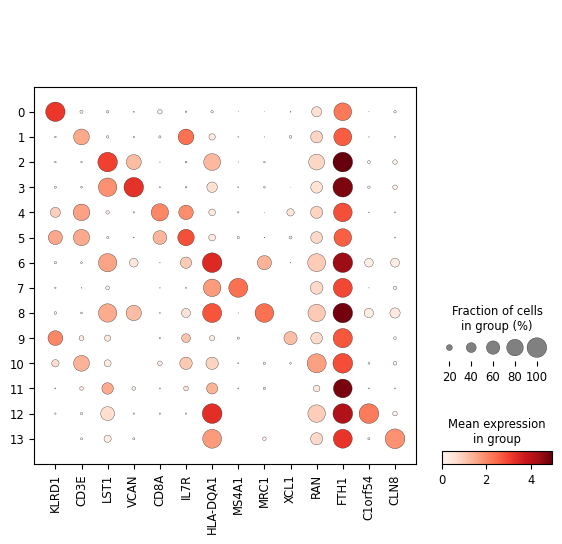

In [33]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

top_genes = [str(g) for g in adata.uns['rank_genes_groups']['names'][0]]
sc.pl.dotplot(adata, var_names=top_genes, groupby='leiden')
